In [1]:
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import mean_squared_error

from datetime import datetime

In [2]:
PATH_TRAINING_A = '../data/preprocessing/normalized/normalized_global_original.npy'
lines_a_noisy = np.load(PATH_TRAINING_A)[:1000]
train_norm, val_norm = train_test_split(lines_a_noisy, test_size=0.1, random_state=42)


In [6]:
timesteps = 64
features = 2
latent_dim = 16 

inputs = Input(shape=(timesteps, features))

# Encoder
encoded = LSTM(64, return_sequences=True)(inputs)
encoded = LSTM(latent_dim)(encoded)

# Bottleneck
decoded = RepeatVector(timesteps)(encoded)

# Decoder
decoded = LSTM(64, return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(features))(decoded)

autoencoder = Model(inputs, decoded)
#autoencoder.summary()


In [7]:
autoencoder.compile(optimizer='adam', loss='mae', metrics=['mae'])

history = autoencoder.fit(
    train_norm, train_norm,
    validation_data=(val_norm, val_norm),
    epochs=200,
    batch_size=32,
    shuffle=True
)


Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - loss: 0.0653 - mae: 0.0653 - val_loss: 0.0214 - val_mae: 0.0214
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0186 - mae: 0.0186 - val_loss: 0.0156 - val_mae: 0.0156
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0143 - mae: 0.0143 - val_loss: 0.0137 - val_mae: 0.0137
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0126 - mae: 0.0126 - val_loss: 0.0116 - val_mae: 0.0116
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0114 - mae: 0.0114 - val_loss: 0.0137 - val_mae: 0.0137
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0112 - mae: 0.0112 - val_loss: 0.0133 - val_mae: 0.0133
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.0094 - mae: 0.0094 - val_loss: 0.0086 - val_mae: 0.0086
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0074 - mae: 0.0074 - val_loss: 0.0068 - val_mae: 0.0068
Epoch 9/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - l

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step


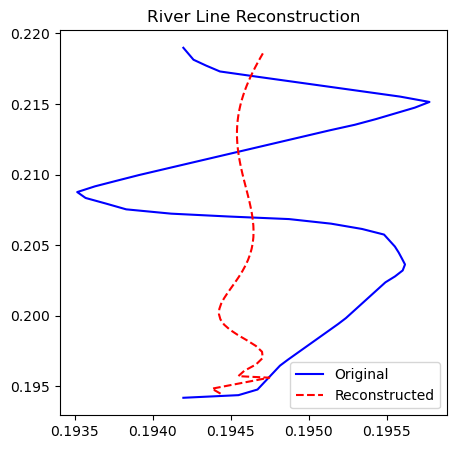

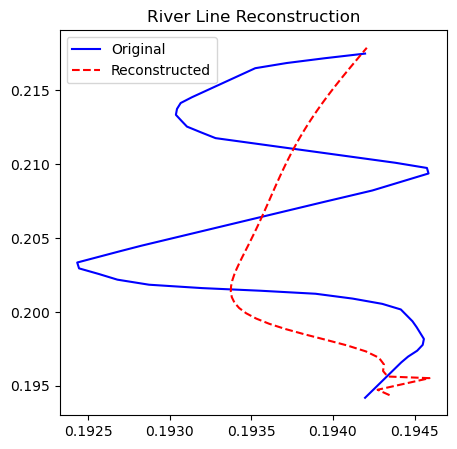

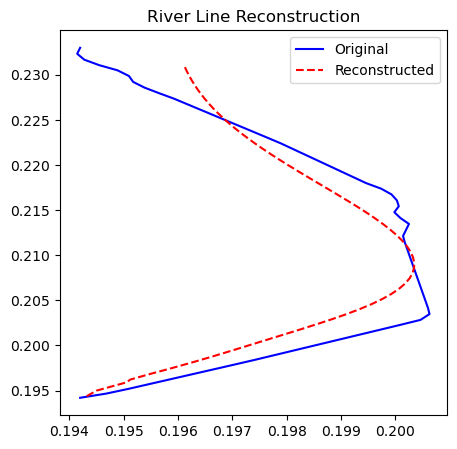

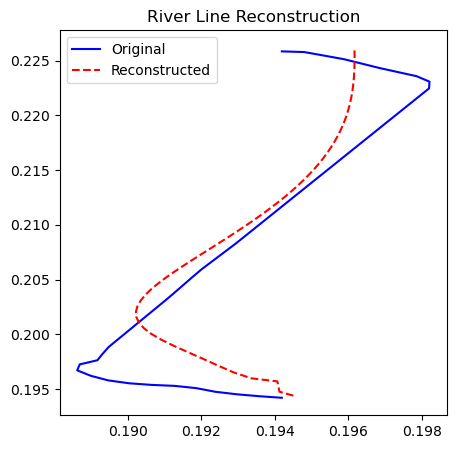

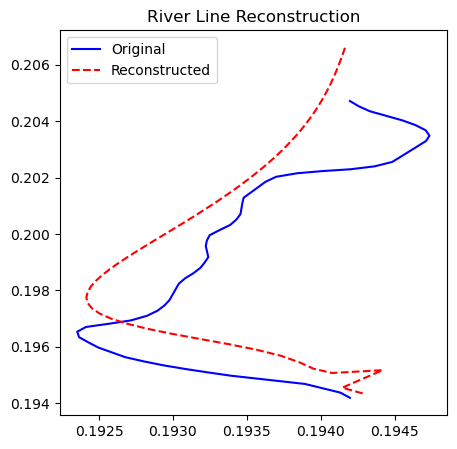

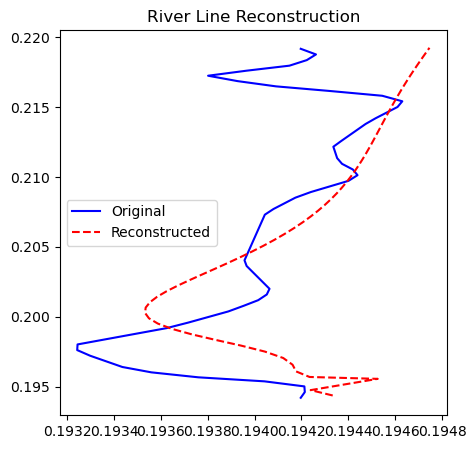

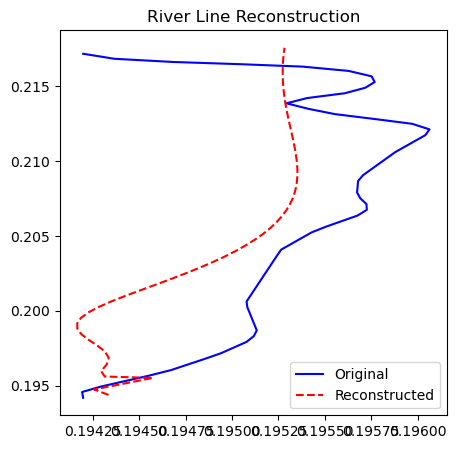

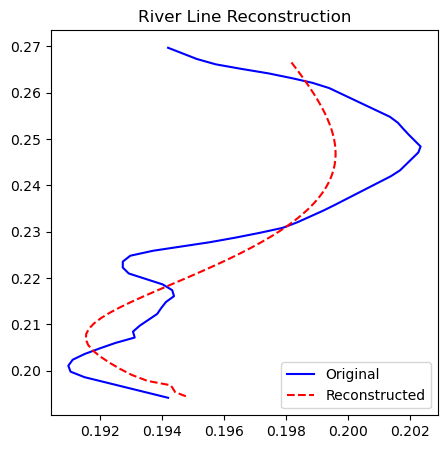

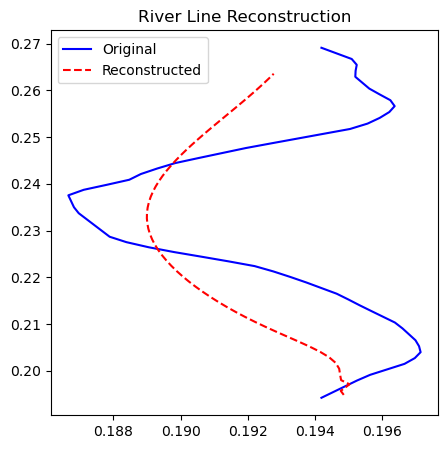

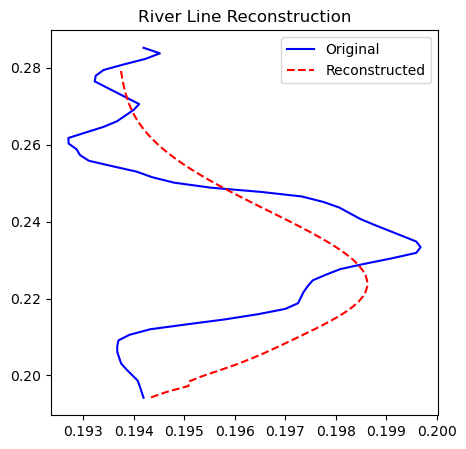

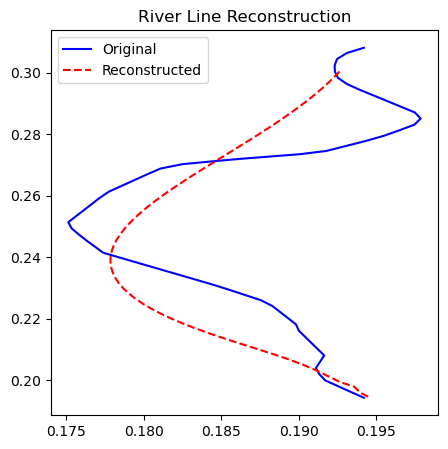

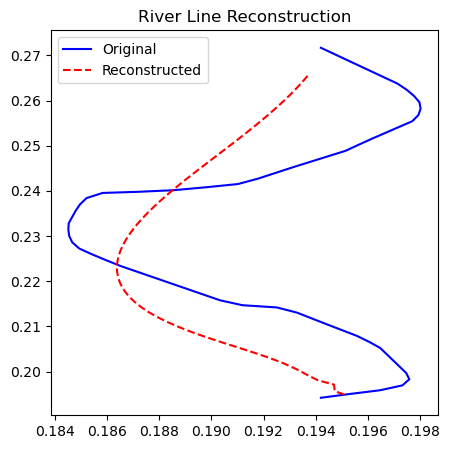

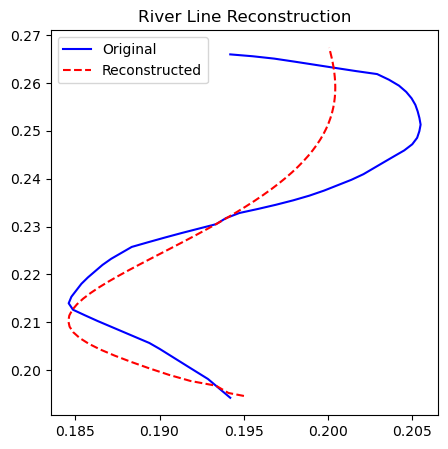

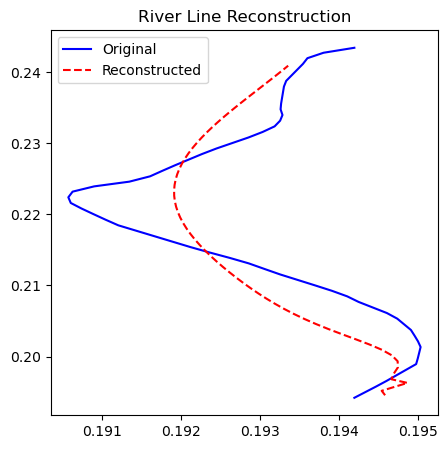

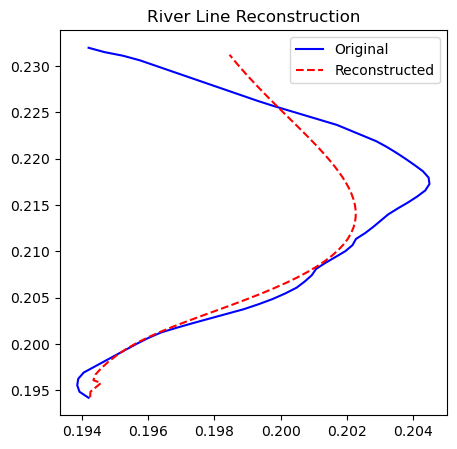

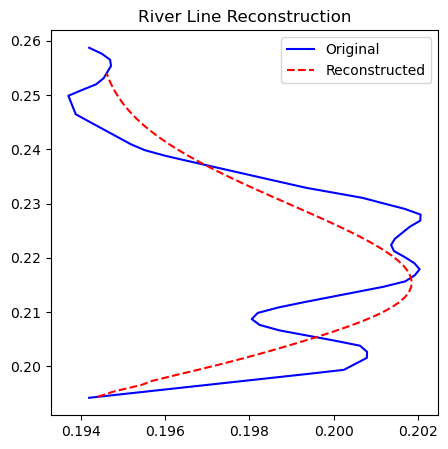

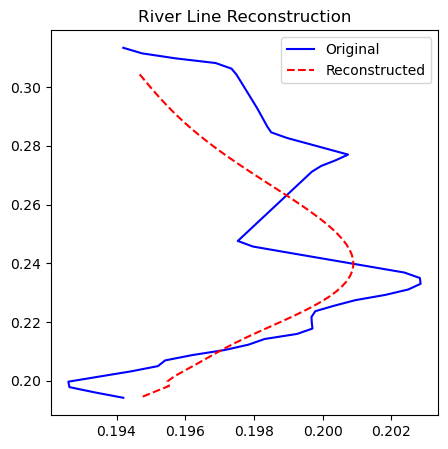

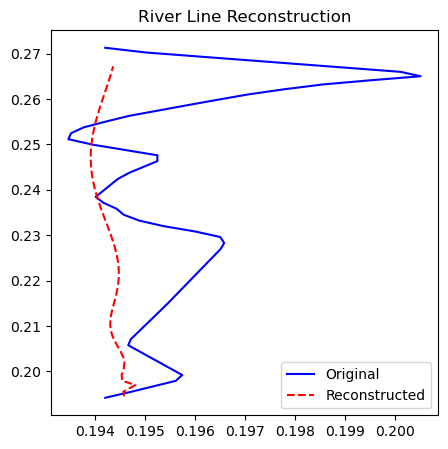

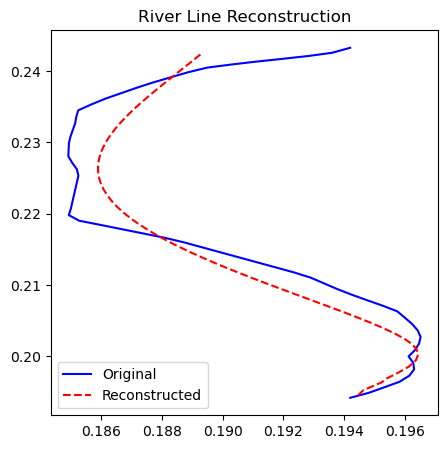

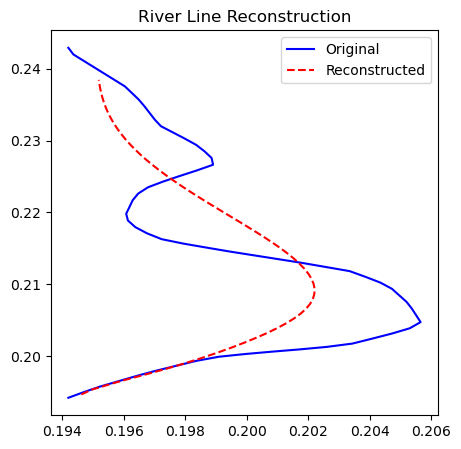

In [8]:
test_norm = np.load(PATH_TRAINING_A)[1000:1200]
reconstructed = autoencoder.predict(test_norm)

for i in range(20):
    plt.figure(figsize=(5,5))
    plt.plot(test_norm[i,:,0], test_norm[i,:,1], 'b-', label='Original')
    plt.plot(reconstructed[i,:,0], reconstructed[i,:,1], 'r--', label='Reconstructed')
    plt.legend()
    plt.title('River Line Reconstruction')
    plt.show()


## SCRIPT

In [ ]:
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
from tensorflow.keras.optimizers import Adam

# Suppose your data arrays are already loaded:
# train_data: (700, 64, 2)
# val_data: (150, 64, 2)
# test_data: (150, 64, 2)

# === Model architecture ===
timesteps = 64
features = 2
latent_dim = 16

inputs = Input(shape=(timesteps, features))
encoded = LSTM(64, return_sequences=True)(inputs)
encoded = LSTM(latent_dim)(encoded)
decoded = RepeatVector(timesteps)(encoded)
decoded = LSTM(64, return_sequences=True)(decoded)
decoded = TimeDistributed(Dense(features))(decoded)

autoencoder = Model(inputs, decoded)
autoencoder.compile(optimizer=Adam(1e-3), loss='mse')

# === Training ===
history = autoencoder.fit(
    train_norm, train_norm,
    epochs=100,
    batch_size=32,
    shuffle=True
)

# === Reconstruction example ===
reconstructed = autoencoder.predict(test_norm)

import matplotlib.pyplot as plt

for i in range(3):
    plt.figure(figsize=(5,5))
    plt.plot(test_norm[i,:,0], test_norm[i,:,1], 'b-', label='Original')
    plt.plot(reconstructed[i,:,0], reconstructed[i,:,1], 'r--', label='Reconstructed')
    plt.legend()
    plt.title('River Line Reconstruction')
    plt.show()
